# HyeBERT Training — Armenian Participle Punctuation

>Trains and evaluates HyeBERT (aking11/hyebert, 66M params, 6 layers) on the Armenian participle punctuation task. Optuna hyperparameter search (25 trials) followed by final training on the negative-filtered corpus (~35K train / ~11K test). Runs on a CUDA-capable GPU

Label scheme (4-class): `O | COMMA_AFTER | BUTH_AFTER | REMOVE_COMMA`

| Setting         | Value                                          |
|-----------------|-------------------------------------------------|
| Base model      | aking11/hyebert (66M params, 6 layers)          |
| Classes         | 4 (O, COMMA_AFTER, BUTH_AFTER, REMOVE_COMMA)   |
| Neg. sampling   | 15%                                             |
| Class weights   | Sqrt inverse frequency                          |
| Train / Val     | ~35K / ~11K sentences                           |
| Optuna trials   | 30 (3 epochs each)                              |

In [1]:
import os
import gc

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
os.environ["CUDA_LAUNCH_BLOCKING"] = "0"

import json
import re
import difflib
import random
import time
import math
import torch

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

import numpy as np
import torch.nn as nn
from collections import Counter
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, f1_score

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    get_linear_schedule_with_warmup,
)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

PyTorch: 2.6.0+cu124
CUDA available: True
  GPU 0: NVIDIA GeForce GTX 1070 Ti
  GPU 1: NVIDIA GeForce GTX 1070 Ti


In [2]:
try:
    import optuna
    from optuna.exceptions import TrialPruned
    OPTUNA_AVAILABLE = True
    print(f"Optuna {optuna.__version__}")
except ImportError:
    OPTUNA_AVAILABLE = False
    print("Optuna not installed — Phase 1 skipped")

Optuna 4.7.0


In [5]:
# ================================================================
# CONFIGURATION
# ================================================================

DATA_DIR = Path("./Data Full")  # <-- ADJUST
RESULTS_DIR = DATA_DIR / "results_clean"

WORKER_FILES = {
    "train": ["worker_0_clean.jsonl", "worker_1_clean.jsonl",
              "worker_2_clean.jsonl", "worker_3_clean.jsonl",
              "worker_6_clean.jsonl"],
    "val":   ["worker_4_clean.jsonl", "worker_5_clean.jsonl"],
}

FIELD_ORIGINAL  = "original"
FIELD_CORRECTED = "corrected"

# 4-class scheme — IDENTICAL to BiLSTM v2
LABEL_MAP = {"O": 0, "COMMA_AFTER": 1, "BUTH_AFTER": 2, "REMOVE_COMMA": 3}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}
LABEL_LIST = list(LABEL_MAP.keys())
NUM_LABELS = len(LABEL_MAP)

MODEL_NAME = "aking11/hyebert"
MAX_LENGTH = 128

NEGATIVE_KEEP_RATIO = 0.15  # same as BiLSTM v2
# Class weights: sqrt inverse frequency (Cui formula saturates at all scales)

SEED = 42

OUTPUT_DIR = Path("hyebert_v3_output")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Labels:  {LABEL_LIST} ({NUM_LABELS} classes)")
print(f"Model:   {MODEL_NAME}")
print(f"Neg ratio: {NEGATIVE_KEEP_RATIO}")
print("Weights:   sqrt inverse frequency")
print(f"Output:  {OUTPUT_DIR}")

Labels:  ['O', 'COMMA_AFTER', 'BUTH_AFTER', 'REMOVE_COMMA'] (4 classes)
Model:   aking11/hyebert
Neg ratio: 0.15
Weights:   sqrt inverse frequency
Output:  hyebert_v3_output


In [6]:
# DEVICE

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"Using CUDA — {torch.cuda.device_count()} GPU(s)")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

Using CUDA — 2 GPU(s)


---
## Section 1: Data Loading with BiLSTM's Label Pipeline

**This is the key difference from previous HyeBERT notebooks.**
We use the EXACT same `tokenize_armenian()` + `difflib.SequenceMatcher`
label generation as `train_bilstm_v2.ipynb` (cells 6 and 8).
Then we map those word-level labels onto HyeBERT's WordPiece tokens.

In [7]:
# ================================================================
# TOKENIZATION + LABEL GENERATION
# with BUTH BUG FIX: Armenian punct (U+055B-055F, U+0589) was
# absorbed into word tokens by the regex [\w\u0530-\u058F]+
# because buth ՝ (U+055D) falls inside the Armenian Unicode block.
# pre-separating Armenian punctuation before regex tokenization is applied.
# ================================================================

# Armenian punctuation marks that fall in U+0530-058F
ARMENIAN_PUNCT = '\u055b\u055c\u055d\u055e\u055f\u0589'

def tokenize_armenian(text):
    '''Splits Armenian text into word and punctuation tokens.
    Based on train_bilstm_v2.ipynb cell 6, with bug fix for Armenian punct.'''
    if not isinstance(text, str) or not text.strip():
        return []
    # FIX: separate Armenian punctuation from adjacent words
    for ch in ARMENIAN_PUNCT:
        text = text.replace(ch, f' {ch} ')
    return re.findall(r'[\w\u0530-\u058F]+|[^\w\s]', text)


def generate_bilstm_labels(orig_tokens, corr_tokens):
    '''Produces per-token label IDs by diffing original vs. corrected.
    Based on train_bilstm_v2.ipynb cell 6.
    Returns list of int labels (same length as orig_tokens).'''
    labels = [0] * len(orig_tokens)
    sm = difflib.SequenceMatcher(None, orig_tokens, corr_tokens)

    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == 'equal':
            continue
        if tag in ('delete', 'replace'):
            for i in range(i1, i2):
                if orig_tokens[i] == ',':
                    labels[i] = LABEL_MAP['REMOVE_COMMA']
        if tag in ('insert', 'replace'):
            for j in range(j1, j2):
                tok = corr_tokens[j]
                if tok == ',' and i1 > 0:
                    labels[i1 - 1] = LABEL_MAP['COMMA_AFTER']
                elif tok == '\u055d' and i1 > 0:
                    labels[i1 - 1] = LABEL_MAP['BUTH_AFTER']
    return labels


def extract_word_labels(orig_tokens, label_ids):
    '''Extract word-level labels, skipping punctuation-only tokens.
    Returns list of (word, label_name) tuples for HyeBERT.

    BiLSTM sees punct as separate tokens (e.g., [word, ",", word]).
    HyeBERT sees only words (WordPiece on words, no punct tokens).

    For REMOVE_COMMA: the BiLSTM puts label 3 on the "," token itself.
    Since HyeBERT doesn't see ",", we move the label to the PRECEDING word.
    '''
    word_labels = []
    pending_remove_comma = False

    for tok, lid in zip(orig_tokens, label_ids):
        is_punct = not re.match(r'[\w\u0530-\u058F]', tok) or tok in ARMENIAN_PUNCT

        if is_punct:
            if lid == LABEL_MAP['REMOVE_COMMA']:
                pending_remove_comma = True
            continue  # skip punct tokens

        # This is a word token
        label_name = INV_LABEL_MAP[lid]

        if pending_remove_comma and word_labels:
            if word_labels[-1][1] == 'O':
                word_labels[-1] = (word_labels[-1][0], 'REMOVE_COMMA')
            pending_remove_comma = False

        word_labels.append((tok, label_name))

    return word_labels


# Quick test — verify buth is now separated
_test1 = tokenize_armenian('word\u055d next')
_test2 = tokenize_armenian('word, comma')
print(f"Buth test: 'word\u055d next' -> {_test1}")
print(f"Comma test: 'word, comma' -> {_test2}")
print(f"\u055d separate: {'\u055d' in _test1}")

Buth test: 'word՝ next' -> ['word', '՝', 'next']
Comma test: 'word, comma' -> ['word', ',', 'comma']
՝ separate: True


In [8]:
# WORKER FILES (using BiLSTM's pipeline)

def load_workers_bilstm_pipeline(file_list, results_dir=RESULTS_DIR):
    '''Load JSONL files using BiLSTM's exact tokenization + difflib labels.
    Returns list of {words: [...], labels: [...]} dicts for HyeBERT.'''
    records = []
    skipped = Counter()

    for fname in file_list:
        path = results_dir / fname
        if not path.exists():
            print(f"  WARNING: {path} not found")
            continue
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip():
                    continue
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    skipped['bad_json'] += 1
                    continue

                original = rec.get(FIELD_ORIGINAL, '')
                corrected = rec.get(FIELD_CORRECTED, '')
                if corrected == 'NO_ACTION_NEEDED':
                    corrected = original
                if not isinstance(corrected, str) or corrected in ('', 'ERROR'):
                    skipped['bad_corrected'] += 1
                    continue

                # BiLSTM tokenization
                orig_tok = tokenize_armenian(original)
                corr_tok = tokenize_armenian(corrected)
                if not orig_tok or not corr_tok:
                    skipped['empty'] += 1
                    continue

                # BiLSTM label generation
                label_ids = generate_bilstm_labels(orig_tok, corr_tok)

                # Extract word-level labels for HyeBERT
                word_labels = extract_word_labels(orig_tok, label_ids)
                if not word_labels:
                    skipped['no_words'] += 1
                    continue

                words = [w for w, l in word_labels]
                labels = [l for w, l in word_labels]

                # Validate
                if any(l not in LABEL_MAP for l in labels):
                    skipped['bad_label'] += 1
                    continue

                records.append({'words': words, 'labels': labels})

    return records, skipped


print("Loading training data (BiLSTM pipeline)...")
train_data_raw, train_skip = load_workers_bilstm_pipeline(WORKER_FILES["train"])
print(f"  Train: {len(train_data_raw):,} ({dict(train_skip)})")

print("Loading validation data (BiLSTM pipeline)...")
val_data_raw, val_skip = load_workers_bilstm_pipeline(WORKER_FILES["val"])
print(f"  Val:   {len(val_data_raw):,} ({dict(val_skip)})")

Loading training data (BiLSTM pipeline)...
  Train: 101,047 ({})
Loading validation data (BiLSTM pipeline)...
  Val:   11,026 ({})


In [9]:
# DATA STATISTICS

def print_stats(data, name="DATA"):
    counts = Counter()
    total = 0
    for rec in data:
        counts.update(rec["labels"])
        total += len(rec["labels"])
    print(f"\n{name}:")
    print(f"  Sentences: {len(data):,}  Tokens: {total:,}")
    for label in LABEL_LIST:
        n = counts.get(label, 0)
        pct = n / total * 100 if total > 0 else 0
        print(f"  {label:15s}: {n:>8,} ({pct:.2f}%)")
    n_pos = sum(1 for r in data if any(l != 'O' for l in r["labels"]))
    print(f"  Positive: {n_pos:,} ({n_pos/len(data)*100:.1f}%)")

print_stats(train_data_raw, "TRAIN (raw, 4-class, BiLSTM pipeline)")
print_stats(val_data_raw, "VAL (raw, 4-class, BiLSTM pipeline)")
print()
print(">>> BUTH_AFTER should now be in the hundreds (not 42 or 1,582).")
print(">>> 42 was BiLSTM broken count (buth absorbed into words).")
print(">>> 1,582 was the punct-stripping pipelines inflated count.")


TRAIN (raw, 4-class, BiLSTM pipeline):
  Sentences: 101,047  Tokens: 2,239,185
  O              : 2,210,937 (98.74%)
  COMMA_AFTER    :    9,126 (0.41%)
  BUTH_AFTER     :   18,297 (0.82%)
  REMOVE_COMMA   :      825 (0.04%)
  Positive: 23,954 (23.7%)

VAL (raw, 4-class, BiLSTM pipeline):
  Sentences: 11,026  Tokens: 245,144
  O              :  241,962 (98.70%)
  COMMA_AFTER    :    1,113 (0.45%)
  BUTH_AFTER     :    1,959 (0.80%)
  REMOVE_COMMA   :      110 (0.04%)
  Positive: 2,639 (23.9%)

>>> BUTH_AFTER should now be in the hundreds (not 42 or 1,582).
>>> 42 was BiLSTM broken count (buth absorbed into words).
>>> 1,582 was the punct-stripping pipelines inflated count.


In [10]:
# NEGATIVE FILTERING — 15%

def apply_negative_filtering(data, keep_ratio, seed=SEED):
    rng = random.Random(seed)
    positive = [r for r in data if any(l != 'O' for l in r["labels"])]
    negative = [r for r in data if all(l == 'O' for l in r["labels"])]
    n_keep = int(len(negative) * keep_ratio)
    rng.shuffle(negative)
    filtered = positive + negative[:n_keep]
    rng.shuffle(filtered)
    print(f"Neg filtering ({keep_ratio}): {len(positive):,} pos + {n_keep:,} neg = {len(filtered):,}")
    return filtered

train_data_filtered = apply_negative_filtering(train_data_raw, NEGATIVE_KEEP_RATIO)
val_data = val_data_raw
print(f"\nVal: {len(val_data):,} (no filtering)")
print_stats(train_data_filtered, "TRAIN (filtered)")

Neg filtering (0.15): 23,954 pos + 11,563 neg = 35,517

Val: 11,026 (no filtering)

TRAIN (filtered):
  Sentences: 35,517  Tokens: 788,037
  O              :  759,789 (96.42%)
  COMMA_AFTER    :    9,126 (1.16%)
  BUTH_AFTER     :   18,297 (2.32%)
  REMOVE_COMMA   :      825 (0.10%)
  Positive: 23,954 (67.4%)


---
## Section 2: Tokenizer, Dataset, Model & Training

In [11]:
# TOKENIZER

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer: {MODEL_NAME}, vocab: {tokenizer.vocab_size:,}")

Tokenizer: aking11/hyebert, vocab: 30,000


In [12]:
# ================================================================
# DATASET — WordPiece alignment for word-level labels
# ================================================================

class HyeBERTDataset(Dataset):
    def __init__(self, data, tokenizer, label2id, max_length=MAX_LENGTH):
        self.data = data
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        rec = self.data[idx]
        words  = rec["words"]
        labels = rec["labels"]

        encoding = self.tokenizer(
            words, is_split_into_words=True,
            truncation=True, max_length=self.max_length,
            padding="max_length", return_tensors="pt")

        word_ids = encoding.word_ids()
        aligned = []
        prev_wid = None
        for wid in word_ids:
            if wid is None:
                aligned.append(-100)
            elif wid != prev_wid:
                aligned.append(self.label2id[labels[wid]])
            else:
                aligned.append(-100)
            prev_wid = wid

        return {"input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(aligned, dtype=torch.long)}

_ds = HyeBERTDataset(train_data_filtered[:2], tokenizer, LABEL_MAP)
_s = _ds[0]
print(f"Sample: input={_s['input_ids'].shape}, active={(_s['labels']!=-100).sum().item()}")

Sample: input=torch.Size([128]), active=5


In [13]:
# ================================================================
# CLASS WEIGHTS — Sqrt inverse frequency
# (Cui beta formula saturates to all-1.0 for any class >100 samples)
# ================================================================

def compute_sqrt_inv_freq_weights(data):
    '''
    weight_c = sqrt(total / (n_classes * count_c)), normalized min=1.0
    
    Sqrt dampening prevents extreme weights on rare classes while still
    giving meaningful signal. With our corrected label distribution:
      O              ~1.0
      COMMA_AFTER    ~9
      BUTH_AFTER     ~6
      REMOVE_COMMA   ~30
    '''
    counts = Counter()
    for rec in data:
        counts.update(rec["labels"])

    total = sum(counts.values())
    n_classes = len(LABEL_LIST)

    weights = {}
    for label in LABEL_LIST:
        n = counts.get(label, 1)
        weights[label] = math.sqrt(total / (n_classes * n))

    min_w = min(weights.values())
    weights = {k: v / min_w for k, v in weights.items()}

    print("Sqrt inverse frequency weights:")
    for label in LABEL_LIST:
        print(f"  {label:15s}: {weights[label]:8.2f}  (n={counts.get(label, 0):,})")

    return torch.tensor([weights[l] for l in LABEL_LIST], dtype=torch.float32)

class_weights = compute_sqrt_inv_freq_weights(train_data_filtered)

Sqrt inverse frequency weights:
  O              :     1.00  (n=759,789)
  COMMA_AFTER    :     9.12  (n=9,126)
  BUTH_AFTER     :     6.44  (n=18,297)
  REMOVE_COMMA   :    30.35  (n=825)


In [14]:
# ================================================================
# MODEL FACTORY
# ================================================================

def create_model(num_labels=NUM_LABELS):
    model = AutoModelForTokenClassification.from_pretrained(
        MODEL_NAME, num_labels=num_labels,
        id2label=INV_LABEL_MAP, label2id=LABEL_MAP,
        ignore_mismatched_sizes=True)
    return model

_m = create_model()
print(f"Model: {sum(p.numel() for p in _m.parameters()):,} params, {NUM_LABELS} classes")
del _m

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: aking11/hyebert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your 

Model: 65,967,364 params, 4 classes


In [15]:
# ================================================================
# TRAINING + EVALUATION — standard CrossEntropyLoss
# ================================================================

def train_one_epoch(model, dataloader, optimizer, scheduler, class_weights, device):
    model.train()
    total_loss, n = 0, 0
    loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device), ignore_index=-100)

    for batch in dataloader:
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids=ids, attention_mask=mask).logits
        loss = loss_fn(logits.view(-1, NUM_LABELS), labels.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        n += 1
    return total_loss / max(n, 1)


@torch.no_grad()
def evaluate(model, dataloader, device, print_report=False):
    model.eval()
    all_preds, all_labels = [], []

    for batch in dataloader:
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["labels"]

        preds = model(input_ids=ids, attention_mask=mask).logits.argmax(-1).cpu()
        for p, l in zip(preds, labels):
            m = l != -100
            all_preds.extend(p[m].tolist())
            all_labels.extend(l[m].tolist())

    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    if print_report:
        print(classification_report(all_labels, all_preds,
              target_names=LABEL_LIST, digits=3, zero_division=0))
        pc, lc = Counter(all_preds), Counter(all_labels)
        print("Distribution:")
        for i, label in enumerate(LABEL_LIST):
            print(f"  {label:15s}: {lc.get(i,0):>7,} true, {pc.get(i,0):>7,} pred")

    return macro_f1

In [16]:
# ================================================================
# FULL TRAINING LOOP
# ================================================================

def train_model(model, train_loader, val_loader, class_weights,
                lr=2e-5, warmup_ratio=0.06, weight_decay=0.01,
                num_epochs=5, patience=2, device=DEVICE,
                save_path=None, verbose=True):
    model.to(device)

    no_decay = {"bias", "LayerNorm.weight", "LayerNorm.bias"}
    param_groups = [
        {"params": [p for n, p in model.named_parameters()
                     if p.requires_grad and not any(nd in n for nd in no_decay)],
         "weight_decay": weight_decay},
        {"params": [p for n, p in model.named_parameters()
                     if p.requires_grad and any(nd in n for nd in no_decay)],
         "weight_decay": 0.0},
    ]
    optimizer = torch.optim.AdamW(param_groups, lr=lr)
    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, int(total_steps * warmup_ratio), total_steps)

    best_f1, best_epoch, wait = 0.0, 0, 0
    history = {"train_loss": [], "val_f1": []}

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        loss = train_one_epoch(model, train_loader, optimizer, scheduler,
                               class_weights, device)
        f1 = evaluate(model, val_loader, device)
        elapsed = time.time() - t0

        history["train_loss"].append(loss)
        history["val_f1"].append(f1)

        if verbose:
            print(f"Epoch {epoch}/{num_epochs} — loss: {loss:.4f}, "
                  f"val_F1: {f1:.4f}, time: {elapsed:.0f}s")

        if f1 > best_f1:
            best_f1, best_epoch, wait = f1, epoch, 0
            if save_path:
                m = model.module if hasattr(model, 'module') else model
                torch.save(m.state_dict(), save_path)
                if verbose: print(f"  -> Saved (F1={best_f1:.4f})")
        else:
            wait += 1
            if wait >= patience:
                if verbose: print(f"  Early stop at epoch {epoch} (best: {best_epoch})")
                break

    if verbose: print(f"\nBest: {best_f1:.4f} at epoch {best_epoch}")
    return best_f1, best_epoch, history

---
## Phase 1: Optuna HPO

In [19]:
SEARCH_EPOCHS = 3
SEARCH_PATIENCE = 2

train_ds_filt = HyeBERTDataset(train_data_filtered, tokenizer, LABEL_MAP)
val_ds = HyeBERTDataset(val_data, tokenizer, LABEL_MAP)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

print(f"Filtered train: {len(train_ds_filt):,}")
print(f"Val:            {len(val_ds):,}")

Filtered train: 35,517
Val:            11,026


In [20]:
def optuna_objective(trial):
    lr = trial.suggest_categorical("lr", [2e-5, 3e-5, 5e-5, 7e-5])
    bs = trial.suggest_categorical("batch_size", [16, 32])
    warmup = trial.suggest_float("warmup_ratio", 0.0, 0.10)
    freeze = trial.suggest_categorical("freeze_layers", [0, 2, 3, 4])

    train_loader = DataLoader(train_ds_filt, batch_size=bs, shuffle=True,
                              num_workers=0, pin_memory=(DEVICE.type=="cuda"))
    
    model = create_model()
    
    # Apply layer freezing
    if freeze > 0:
        for param in model.bert.embeddings.parameters():
            param.requires_grad = False
        for layer_idx in range(min(freeze, len(model.bert.encoder.layer))):
            for param in model.bert.encoder.layer[layer_idx].parameters():
                param.requires_grad = False

    best_f1, _, _ = train_model(model, train_loader, val_loader, class_weights,
                                lr=lr, warmup_ratio=warmup,
                                num_epochs=SEARCH_EPOCHS, patience=SEARCH_PATIENCE,
                                device=DEVICE, save_path=None, verbose=False)

    del model, train_loader
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    print(f"  Trial {trial.number}: lr={lr}, bs={bs}, warmup={warmup:.3f}, "
          f"freeze={freeze} -> F1={best_f1:.4f}")
    return best_f1


In [21]:
N_TRIALS = 30

if OPTUNA_AVAILABLE:
    study = optuna.create_study(direction="maximize",
        study_name="hyebert_v3_matched",
        sampler=optuna.samplers.TPESampler(seed=SEED))
    print(f"Starting Optuna: {N_TRIALS} trials, {SEARCH_EPOCHS} epochs each")
    print(f"Search space: lr x bs x warmup x freeze_layers")
    print("=" * 60)
    study.optimize(optuna_objective, n_trials=N_TRIALS)
    print("\n" + "=" * 60)
    print(f"Best: #{study.best_trial.number}, F1={study.best_value:.4f}")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")
else:
    print("Optuna not available")


[I 2026-03-28 02:55:57,622] A new study created in memory with name: hyebert_v3_matched


Starting Optuna: 30 trials, 3 epochs each
Search space: lr x bs x warmup x freeze_layers


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: aking11/hyebert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your 

  Trial 0: lr=3e-05, bs=16, warmup=0.006, freeze=0 -> F1=0.3498


...

BertForTokenClassification LOAD REPORT from: aking11/hyebert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your 

  Trial 28: lr=5e-05, bs=16, warmup=0.046, freeze=4 -> F1=0.3272


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: aking11/hyebert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your 

  Trial 29: lr=3e-05, bs=16, warmup=0.012, freeze=0 -> F1=0.3538

Best: #16, F1=0.3804
  lr: 7e-05
  batch_size: 16
  warmup_ratio: 0.03731403198041134
  freeze_layers: 0


In [22]:
if OPTUNA_AVAILABLE and study.best_trial:
    best_config = dict(study.best_params)  # includes freeze_layers
else:
    best_config = {"lr": 7e-05, "batch_size": 16, "warmup_ratio": 0.05, "freeze_layers": 0}

with open(OUTPUT_DIR / "best_config.json", "w") as f:
    json.dump(best_config, f, indent=2)
print(f"Config: {best_config}")


Config: {'lr': 7e-05, 'batch_size': 16, 'warmup_ratio': 0.03731403198041134, 'freeze_layers': 0}


---
## Phase 2: Final Training

In [23]:
config_path = OUTPUT_DIR / "best_config.json"
if config_path.exists():
    with open(config_path) as f:
        best_config = json.load(f)
    print("Loaded config:")
else:
    best_config = {"lr": 7e-05, "batch_size": 16, "warmup_ratio": 0.05, "freeze_layers": 0}
    print("Manual config:")
print(json.dumps(best_config, indent=2))

Loaded config:
{
  "lr": 7e-05,
  "batch_size": 16,
  "warmup_ratio": 0.03731403198041134,
  "freeze_layers": 0
}


In [24]:
# Full dataset (same 15% neg filtering)
train_data_final = apply_negative_filtering(train_data_raw, NEGATIVE_KEEP_RATIO)
print_stats(train_data_final, "FINAL TRAIN")
class_weights_final = compute_sqrt_inv_freq_weights(train_data_final)

Neg filtering (0.15): 23,954 pos + 11,563 neg = 35,517

FINAL TRAIN:
  Sentences: 35,517  Tokens: 788,037
  O              :  759,789 (96.42%)
  COMMA_AFTER    :    9,126 (1.16%)
  BUTH_AFTER     :   18,297 (2.32%)
  REMOVE_COMMA   :      825 (0.10%)
  Positive: 23,954 (67.4%)
Sqrt inverse frequency weights:
  O              :     1.00  (n=759,789)
  COMMA_AFTER    :     9.12  (n=9,126)
  BUTH_AFTER     :     6.44  (n=18,297)
  REMOVE_COMMA   :    30.35  (n=825)


In [25]:
FINAL_EPOCHS = 10
FINAL_PATIENCE = 2

train_ds_final = HyeBERTDataset(train_data_final, tokenizer, LABEL_MAP)
if 'val_ds' not in dir():
    val_ds = HyeBERTDataset(val_data, tokenizer, LABEL_MAP)

train_loader = DataLoader(train_ds_final, batch_size=best_config["batch_size"],
                          shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

model = create_model()

# Applying layer freezing from Optuna
FINAL_FREEZE = best_config.get("freeze_layers", 0)
if FINAL_FREEZE > 0:
    for param in model.bert.embeddings.parameters():
        param.requires_grad = False
    for layer_idx in range(min(FINAL_FREEZE, len(model.bert.encoder.layer))):
        for param in model.bert.encoder.layer[layer_idx].parameters():
            param.requires_grad = False
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_p = sum(p.numel() for p in model.parameters())
    print(f"Frozen: layers 0-{FINAL_FREEZE-1} + embeddings ({trainable:,}/{total_p:,} trainable)")

model.to(DEVICE)

if torch.cuda.device_count() > 1:
    print(f"DataParallel: {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

save_path = OUTPUT_DIR / "hyebert_v3_best.pt"

print(f"\nFinal Training (4-class, matched pipeline):")
print(f"  Train: {len(train_ds_final):,}, Val: {len(val_ds):,}")
print(f"  Config: {best_config}")
print(f"  Epochs: {FINAL_EPOCHS}, patience={FINAL_PATIENCE}")
print("=" * 60)

best_f1, best_epoch, history = train_model(
    model, train_loader, val_loader, class_weights_final,
    lr=best_config["lr"], warmup_ratio=best_config["warmup_ratio"],
    num_epochs=FINAL_EPOCHS, patience=FINAL_PATIENCE,
    device=DEVICE, save_path=str(save_path), verbose=True)

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: aking11/hyebert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your 

DataParallel: 2 GPUs

Final Training (4-class, matched pipeline):
  Train: 35,517, Val: 11,026
  Config: {'lr': 7e-05, 'batch_size': 16, 'warmup_ratio': 0.03731403198041134, 'freeze_layers': 0}
  Epochs: 10, patience=2


C:\Users\Albert\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\cuda\nccl.py:16: UserWarning: PyTorch is not compiled with NCCL support
  warnings.warn("PyTorch is not compiled with NCCL support")


Epoch 1/10 — loss: 0.6198, val_F1: 0.3629, time: 548s
  -> Saved (F1=0.3629)


...

Epoch 8/10 — loss: 0.0346, val_F1: 0.3993, time: 557s


C:\Users\Albert\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\cuda\nccl.py:16: UserWarning: PyTorch is not compiled with NCCL support
  warnings.warn("PyTorch is not compiled with NCCL support")


Epoch 9/10 — loss: 0.0240, val_F1: 0.4110, time: 557s
  -> Saved (F1=0.4110)


C:\Users\Albert\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\cuda\nccl.py:16: UserWarning: PyTorch is not compiled with NCCL support
  warnings.warn("PyTorch is not compiled with NCCL support")


Epoch 10/10 — loss: 0.0162, val_F1: 0.4098, time: 557s

Best: 0.4110 at epoch 9


In [27]:
# ================================================================
# FILTERED VAL (for BiLSTM comparison)
# ================================================================

val_data_filt = apply_negative_filtering(val_data_raw, NEGATIVE_KEEP_RATIO)
val_ds_filt = HyeBERTDataset(val_data_filt, tokenizer, LABEL_MAP)
val_loader_filt = DataLoader(val_ds_filt, batch_size=32, shuffle=False)

print("\n--- FILTERED val ---")
filt_f1 = evaluate(m, val_loader_filt, DEVICE, print_report=True)
print(f"Macro-F1 (4-class, filtered): {filt_f1:.4f}")

Neg filtering (0.15): 2,639 pos + 1,258 neg = 3,897

--- FILTERED val ---
              precision    recall  f1-score   support

           O      0.977     0.982     0.980     83461
 COMMA_AFTER      0.447     0.312     0.367      1113
  BUTH_AFTER      0.413     0.397     0.405      1959
REMOVE_COMMA      0.324     0.109     0.163       110

    accuracy                          0.959     86643
   macro avg      0.540     0.450     0.479     86643
weighted avg      0.956     0.959     0.958     86643

Distribution:
  O              :  83,461 true,  83,946 pred
  COMMA_AFTER    :   1,113 true,     776 pred
  BUTH_AFTER     :   1,959 true,   1,884 pred
  REMOVE_COMMA   :     110 true,      37 pred
Macro-F1 (4-class, filtered): 0.4788


In [28]:
# DETAILED EVALUATION

print("=" * 60)
print("FINAL EVALUATION (4-class, BiLSTM-matched pipeline)")
print("=" * 60)

m = model.module if hasattr(model, 'module') else model
m.load_state_dict(torch.load(save_path, map_location=DEVICE, weights_only=True))
m.to(DEVICE)

print("\n--- UNFILTERED val ---")
final_f1 = evaluate(m, val_loader, DEVICE, print_report=True)
print(f"Macro-F1 (4-class, unfiltered): {final_f1:.4f}")

# Also eval as 3-class (remap REMOVE_COMMA → O) for cross-comparison
@torch.no_grad()
def evaluate_3class_remap(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    for batch in dataloader:
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["labels"]
        preds = model(input_ids=ids, attention_mask=mask).logits.argmax(-1).cpu()
        for p, l in zip(preds, labels):
            m = l != -100
            pl = [0 if x==3 else x for x in p[m].tolist()]
            ll = [0 if x==3 else x for x in l[m].tolist()]
            all_preds.extend(pl)
            all_labels.extend(ll)
    return f1_score(all_labels, all_preds, labels=[0,1,2], average="macro", zero_division=0)

f1_3c = evaluate_3class_remap(m, val_loader, DEVICE)
ins_f1 = f1_score([], [], average="macro", zero_division=0)  # placeholder

# Insertion-only
@torch.no_grad()
def eval_insertion_only(model, dataloader, device):
    model.eval()
    all_p, all_l = [], []
    for batch in dataloader:
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["labels"]
        preds = model(input_ids=ids, attention_mask=mask).logits.argmax(-1).cpu()
        for p, l in zip(preds, labels):
            m = l != -100
            all_p.extend(p[m].tolist())
            all_l.extend(l[m].tolist())
    return f1_score(all_l, all_p, labels=[1, 2], average="macro", zero_division=0)

ins_f1 = eval_insertion_only(m, val_loader, DEVICE)

print(f"\n3-class remap F1: {f1_3c:.4f}")
print(f"Insertion-only F1: {ins_f1:.4f}")

FINAL EVALUATION (4-class, BiLSTM-matched pipeline)

--- UNFILTERED val ---
              precision    recall  f1-score   support

           O      0.992     0.982     0.987    241922
 COMMA_AFTER      0.222     0.312     0.260      1113
  BUTH_AFTER      0.203     0.397     0.269      1959
REMOVE_COMMA      0.156     0.109     0.128       110

    accuracy                          0.974    245104
   macro avg      0.393     0.450     0.411    245104
weighted avg      0.982     0.974     0.978    245104

Distribution:
  O              : 241,922 true, 239,642 pred
  COMMA_AFTER    :   1,113 true,   1,561 pred
  BUTH_AFTER     :   1,959 true,   3,824 pred
  REMOVE_COMMA   :     110 true,      77 pred
Macro-F1 (4-class, unfiltered): 0.4110


ValueError: Found empty input array (e.g., `y_true` or `y_pred`) while a minimum of 1 sample is required.

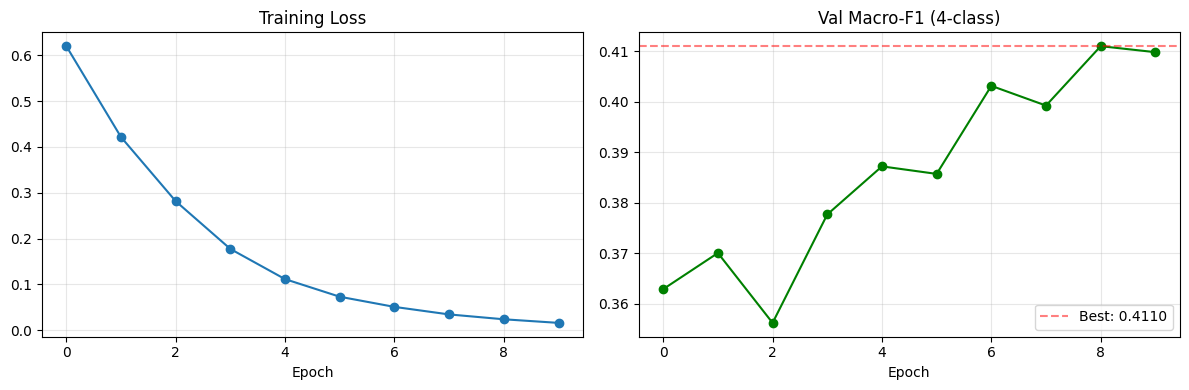

In [30]:
# TRAINING CURVES

try:
    import matplotlib.pyplot as plt
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    a1.plot(history["train_loss"], marker='o')
    a1.set_title("Training Loss"); a1.set_xlabel("Epoch"); a1.grid(True, alpha=0.3)
    a2.plot(history["val_f1"], marker='o', color='green')
    a2.axhline(y=best_f1, color='red', linestyle='--', alpha=0.5, label=f'Best: {best_f1:.4f}')
    a2.set_title("Val Macro-F1 (4-class)"); a2.set_xlabel("Epoch"); a2.legend(); a2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "training_curves_v3.png", dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print("matplotlib not available")

In [ ]:
# ================================================================
# SAVE RESULTS
# ================================================================

results = {
    "model": "hyebert",
    "num_labels": NUM_LABELS,
    "labels": LABEL_LIST,
    "weighting": "sqrt_inverse_frequency",
    "neg_keep_ratio": NEGATIVE_KEEP_RATIO,
    "best_f1_unfiltered": final_f1,
    "best_f1_filtered": filt_f1,
    "f1_3class_remap": f1_3c,
    "best_epoch": best_epoch,
    "config": best_config,
    "history": history}

with open(OUTPUT_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved to {OUTPUT_DIR / 'results.json'}")

---
## Summary

This notebook trains HyeBERT (aking11/hyebert, 66M params) on the Armenian participle
punctuation task. Optuna selected full unfreezing with sqrt inverse frequency class weights.
The model achieved a macro-F1 of 0.411 on the unfiltered validation set, underperforming
the 12-layer mBERT (0.4854), consistent with the depth-over-specificity finding reported
in the paper.

**Outputs:** `hyebert_v3_best.pt`, `results.json`
